# Import required libraries

In [1]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

/tmp/ipykernel_5494/2710679580.py:5: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


# Load the Titanic dataset

In [3]:
df = sns.load_dataset('titanic')

# Display the first five rows

In [4]:
# أول 5 صفوف
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Display the last five rows

In [5]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


#Display rows and columns

In [6]:
df.shape

(891, 15)

# Check dataset information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


# Display summary statistics for numerical features

In [8]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Check missing values

In [9]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


# Fill or remove missing values

In [10]:
df["age"]=df['age'].fillna(df['age'].median())

In [11]:
df["embark_town"]=df['embark_town'].fillna(df['embark_town'].mode()[0])

In [12]:
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])

# Display descriptive statistics for all columns (numerical and categorical)

In [13]:
df.describe(include='object')

,sex,embarked,who,embark_town,alive
count,891,891,891,891,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,646,537,646,549


# Remove columns that do not help prediction

In [14]:
df.drop(columns="deck",inplace=True)

#check duplicated

In [15]:
df.duplicated().sum()

np.int64(116)

#drop duplicated

In [16]:
df.drop_duplicates(inplace=True)

# Display unique values for each column

In [17]:
df['embarked'].value_counts()

,count
embarked,
S,562
C,155
Q,58


In [18]:
df['sex'].value_counts()

,count
sex,
male,483
female,292


In [19]:
df['who'].value_counts()

,count
who,
man,443
woman,250
child,82


# Clean text columns by removing extra spaces and converting text to lowercase

In [20]:
df = df.apply(
    lambda col: col.str.strip().str.lower() if col.dtype == "object" else col
)

In [21]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,s,Third,man,True,southampton,no,False
1,1,1,female,38.0,1,0,71.2833,c,First,woman,False,cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,s,Third,woman,False,southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,s,First,woman,False,southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,s,Third,man,True,southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,q,Third,woman,False,queenstown,no,False
887,1,1,female,19.0,0,0,30.0000,s,First,woman,False,southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,s,Third,woman,False,southampton,no,False
889,1,1,male,26.0,0,0,30.0000,c,First,man,True,cherbourg,yes,True


# Check dataset information

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     775 non-null    int64   
 1   pclass       775 non-null    int64   
 2   sex          775 non-null    object  
 3   age          775 non-null    float64 
 4   sibsp        775 non-null    int64   
 5   parch        775 non-null    int64   
 6   fare         775 non-null    float64 
 7   embarked     775 non-null    object  
 8   class        775 non-null    category
 9   who          775 non-null    object  
 10  adult_male   775 non-null    bool    
 11  embark_town  775 non-null    object  
 12  alive        775 non-null    object  
 13  alone        775 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 75.1+ KB


# Visualize outliers in the Age column using a box plot

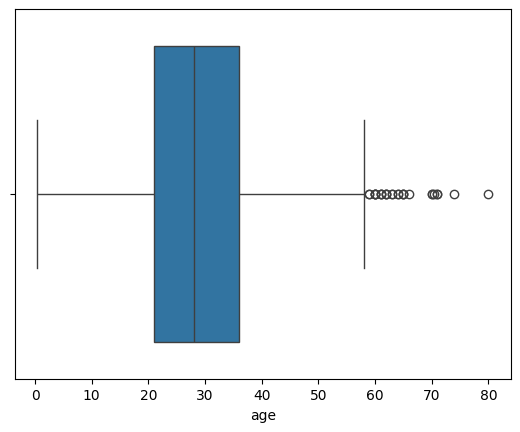

In [23]:
sns.boxplot(x=df["age"])
plt.show()

# Display descriptive statistics for all columns (numerical and categorical)

In [24]:
df.describe(include='object')

,sex,embarked,who,embark_town,alive
count,775,775,775,775,775
unique,2,3,3,3,2
top,male,s,man,southampton,no
freq,483,562,443,562,455


#drop tow columns

In [25]:
df.drop(columns=["embark_town", "alive"], inplace=True)

#One Hot Encodeing

In [26]:
df = pd.get_dummies(df, columns=["embarked","who","class"], dtype=int)

In [27]:
df

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone,embarked_c,embarked_q,embarked_s,who_child,who_man,who_woman,class_First,class_Second,class_Third
0,0,3,male,22.0,1,0,7.2500,True,False,0,0,1,0,1,0,0,0,1
1,1,1,female,38.0,1,0,71.2833,False,False,1,0,0,0,0,1,1,0,0
2,1,3,female,26.0,0,0,7.9250,False,True,0,0,1,0,0,1,0,0,1
3,1,1,female,35.0,1,0,53.1000,False,False,0,0,1,0,0,1,1,0,0
4,0,3,male,35.0,0,0,8.0500,True,True,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,False,False,0,1,0,0,0,1,0,0,1
887,1,1,female,19.0,0,0,30.0000,False,True,0,0,1,0,0,1,1,0,0
888,0,3,female,28.0,1,2,23.4500,False,False,0,0,1,0,0,1,0,0,1
889,1,1,male,26.0,0,0,30.0000,True,True,1,0,0,0,1,0,1,0,0


#Display rows and columns

In [28]:
df.shape

(775, 18)

#Drop duplicated

In [29]:
df.drop_duplicates(inplace=True)

In [31]:
df

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone,embarked_c,embarked_q,embarked_s,who_child,who_man,who_woman,class_First,class_Second,class_Third
0,0,3,male,22.0,1,0,7.2500,True,False,0,0,1,0,1,0,0,0,1
1,1,1,female,38.0,1,0,71.2833,False,False,1,0,0,0,0,1,1,0,0
2,1,3,female,26.0,0,0,7.9250,False,True,0,0,1,0,0,1,0,0,1
3,1,1,female,35.0,1,0,53.1000,False,False,0,0,1,0,0,1,1,0,0
4,0,3,male,35.0,0,0,8.0500,True,True,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,False,False,0,1,0,0,0,1,0,0,1
887,1,1,female,19.0,0,0,30.0000,False,True,0,0,1,0,0,1,1,0,0
888,0,3,female,28.0,1,2,23.4500,False,False,0,0,1,0,0,1,0,0,1
889,1,1,male,26.0,0,0,30.0000,True,True,1,0,0,0,1,0,1,0,0


#LebelEncoder in column sex

In [32]:
le=LabelEncoder()
df['sex']=le.fit_transform(df['sex'])
df

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone,embarked_c,embarked_q,embarked_s,who_child,who_man,who_woman,class_First,class_Second,class_Third
0,0,3,1,22.0,1,0,7.2500,True,False,0,0,1,0,1,0,0,0,1
1,1,1,0,38.0,1,0,71.2833,False,False,1,0,0,0,0,1,1,0,0
2,1,3,0,26.0,0,0,7.9250,False,True,0,0,1,0,0,1,0,0,1
3,1,1,0,35.0,1,0,53.1000,False,False,0,0,1,0,0,1,1,0,0
4,0,3,1,35.0,0,0,8.0500,True,True,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,0,39.0,0,5,29.1250,False,False,0,1,0,0,0,1,0,0,1
887,1,1,0,19.0,0,0,30.0000,False,True,0,0,1,0,0,1,1,0,0
888,0,3,0,28.0,1,2,23.4500,False,False,0,0,1,0,0,1,0,0,1
889,1,1,1,26.0,0,0,30.0000,True,True,1,0,0,0,1,0,1,0,0


#Replace true and false to (1,0)

In [33]:
df['adult_male'] = df['adult_male'].replace({True: 1, False: 0})
df['alone'] = df['alone'].replace({True: 1, False: 0})
df

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone,embarked_c,embarked_q,embarked_s,who_child,who_man,who_woman,class_First,class_Second,class_Third
0,0,3,1,22.0,1,0,7.2500,1,0,0,0,1,0,1,0,0,0,1
1,1,1,0,38.0,1,0,71.2833,0,0,1,0,0,0,0,1,1,0,0
2,1,3,0,26.0,0,0,7.9250,0,1,0,0,1,0,0,1,0,0,1
3,1,1,0,35.0,1,0,53.1000,0,0,0,0,1,0,0,1,1,0,0
4,0,3,1,35.0,0,0,8.0500,1,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,0,39.0,0,5,29.1250,0,0,0,1,0,0,0,1,0,0,1
887,1,1,0,19.0,0,0,30.0000,0,1,0,0,1,0,0,1,1,0,0
888,0,3,0,28.0,1,2,23.4500,0,0,0,0,1,0,0,1,0,0,1
889,1,1,1,26.0,0,0,30.0000,1,1,1,0,0,0,1,0,1,0,0


# Create a comprehensive exploratory data analysis (EDA) report

In [34]:
profile=ProfileReport(df,title='  Report  ')
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 18/18 [00:00<00:00, 43.09it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# Visualize the correlation matrix using a heatmap

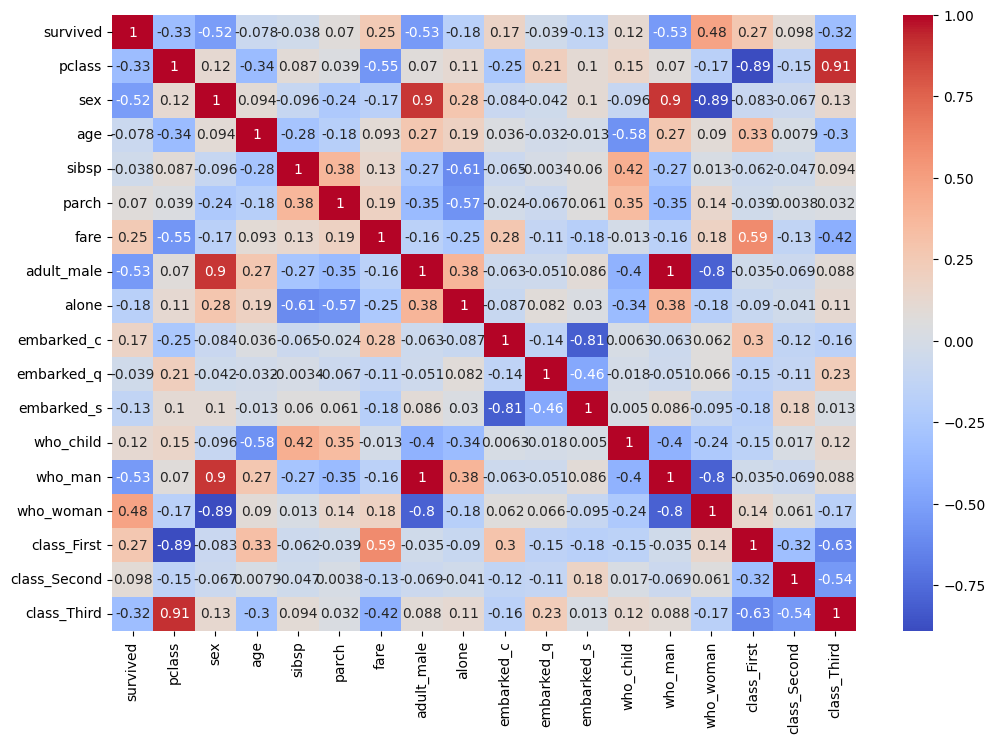

In [35]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

# Separate features and target

In [36]:
X = df.drop('survived', axis=1)
y = df['survived']

# Split data into training and testing sets

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

# Scale numerical features using StandardScaler

In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Logistic Regression model

In [39]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=42)

# Predict survival on test data

In [40]:
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Evaluate model performance

In [41]:
train_acc_lr = lr.score(X_train_scaled, y_train)
print("Train Accuracy:", train_acc_lr)

Train Accuracy: 0.8048387096774193


In [42]:
test_acc_lr = accuracy_score(y_test, y_pred_lr)
print("Test Accuracy:", test_acc_lr)

Test Accuracy: 0.8129032258064516


# Generate a classification report for the Logistic Regression model

In [43]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85        95
           1       0.77      0.73      0.75        60

    accuracy                           0.81       155
   macro avg       0.80      0.80      0.80       155
weighted avg       0.81      0.81      0.81       155



# Display confusion matrix

In [44]:
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[82 13]
 [16 44]]


# Visualize the confusion matrix for model evaluation

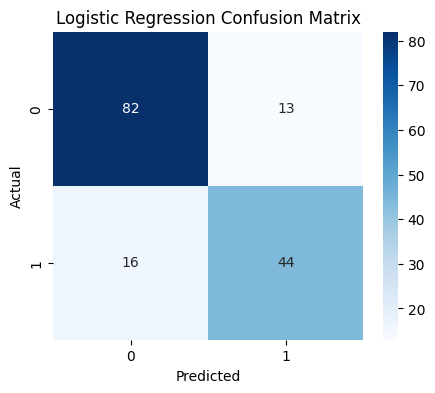

In [45]:
plt.figure(figsize=(5,4))
sns.heatmap( cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Visualize between train and test

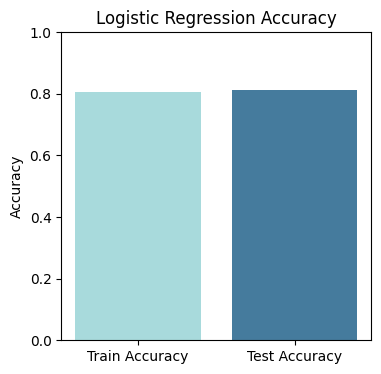

In [46]:
plt.figure(figsize=(4,4))

plt.bar(
    ["Train Accuracy", "Test Accuracy"],
    [train_acc_lr, test_acc_lr],
    color=["#A8DADC", "#457B9D"]
)

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title("Logistic Regression Accuracy")

plt.show()

# Train the Random forestclassifier model

In [47]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42)

In [48]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# Predict survival on test data

In [49]:
y_pred_rf = rf.predict(X_test)

# Evaluate model performance

In [50]:
train_acc_rf = rf.score(X_train, y_train)

print("Train Accuracy:", train_acc_rf)

Train Accuracy: 0.9806451612903225


In [51]:
test_acc_rf = accuracy_score(y_test, y_pred_rf)

print("Test Accuracy:", test_acc_rf)

Test Accuracy: 0.7419354838709677


# Generate a classification report for the Random Forestclassifier model

In [52]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79        95
           1       0.66      0.68      0.67        60

    accuracy                           0.74       155
   macro avg       0.73      0.73      0.73       155
weighted avg       0.74      0.74      0.74       155



# Display and Visualize confusion matrix

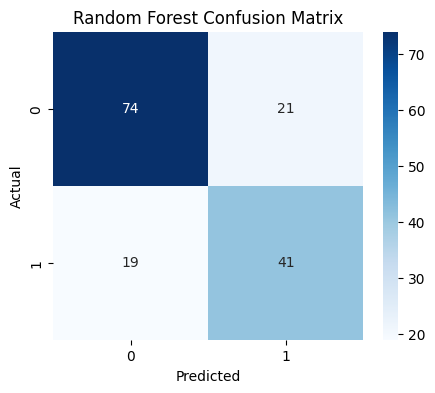

In [53]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

# Visualize between train and test (accuracy)

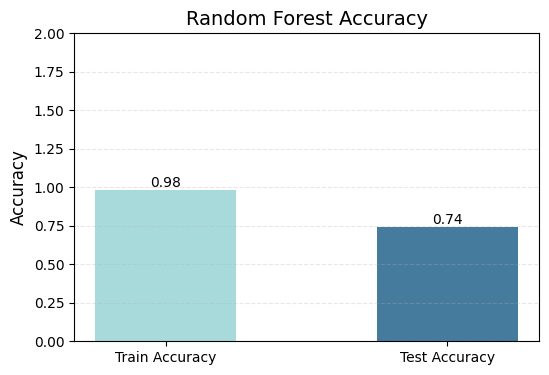

In [54]:
plt.figure(figsize=(6,4))

bars = plt.bar(
    ["Train Accuracy", "Test Accuracy"],
    [train_acc_rf, test_acc_rf],
    color=["#A8DADC", "#457B9D"],
    width=0.5
)

plt.ylim(0,2)

plt.ylabel("Accuracy", fontsize=12)

plt.title("Random Forest Accuracy", fontsize=14)

plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y+0.02,
        f"{y:.2f}",
        ha="center"
    )

plt.show()

# Train Accuracy = 1.00
# Test Accuracy = 0.82

**The Random Forest model shows signs of overfitting because the training accuracy is significantly higher than the testing accuracy. Although it performs perfectly on the training data, its performance decreases on unseen data.**

# Install the XGBoost library


In [55]:
!pip install xgboost

# Import the XGBoost library

In [56]:
from xgboost import XGBClassifier

In [57]:
xgb = XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3, random_state=42, eval_metric='logloss')

In [58]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

# Predict survival on test data

In [59]:
y_pred_xgb = xgb.predict(X_test)

# Evaluate model performance

In [60]:
train_acc_xgb = xgb.score(X_train, y_train)

print("Train Accuracy:", train_acc_xgb)

Train Accuracy: 0.8661290322580645


In [61]:
test_acc_xgb = accuracy_score(y_test, y_pred_xgb)
print("Test Accuracy:", test_acc_xgb)

Test Accuracy: 0.8


# Generate a classification report for the Random Forestclassifier model

In [62]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84        95
           1       0.78      0.67      0.72        60

    accuracy                           0.80       155
   macro avg       0.80      0.78      0.78       155
weighted avg       0.80      0.80      0.80       155



# Display and Visualize confusion matrix

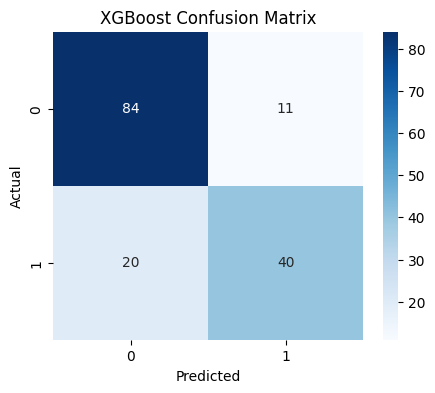

In [63]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

# Visualize between train and test (accuracy)

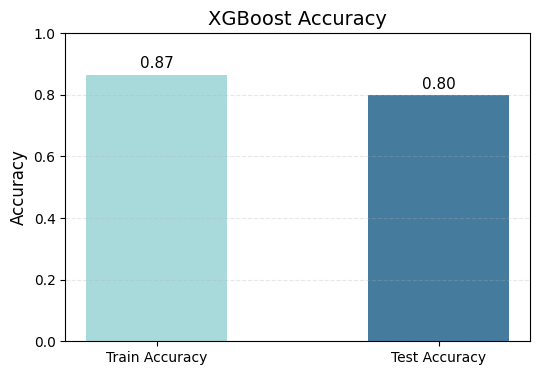

In [64]:
plt.figure(figsize=(6,4))

bars = plt.bar(
    ["Train Accuracy", "Test Accuracy"],
    [train_acc_xgb, test_acc_xgb],
    color=["#A8DADC", "#457B9D"],
    width=0.5
)

plt.ylim(0,1)

plt.ylabel("Accuracy", fontsize=12)

plt.title("XGBoost Accuracy", fontsize=14)

plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.02,
        f"{y:.2f}",
        ha="center",
        fontsize=11
    )

plt.show()